In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import ast
import pingouin as pg
import pandas as pd
import sys
sys.path.extend(['/Users/amonast/Documents/GitHub/Engram_2P/Engram_2P',
                 '/Users/amonast/Documents/GitHub/Engram_2P/Amy_2P/analysis/correlation'])
from util_func import distRiemLE
from PairwiseCorrelations.pairwise_corr_utils import filter_windows_by_mask,sample_equal_frames,mask_from_windows
from Correlation import correlation
from utilities.animal import animal 
import pickle
save_dir = '/Users/amonast/Desktop/Tone2P/Analysis/correlation/corrmats-nobin'

In [2]:
animals = ['997B','939L','194L','M1N','M2L','F7N','M8BL2','M9BR2','639N']
file_key = '/Users/amonast/Desktop/Tone2P/Data_info_TFC.csv'
base_dir = '/Users/amonast/Desktop/Tone2P'
sessions = ['Baseline','Recall1']

def mask_valid_pair(mat_a, mat_b):
    """
    Remove rows/cols where entire row is 999 sentinel value in either matrix.
    Applies the same mask to both to keep cell populations aligned.
    """
    if not ((mat_a == 999).any() | (mat_b == 999).any()):
        return mat_a, mat_b
    
    bad = (mat_a == 999).all(axis=1) | (mat_b == 999).all(axis=1)
    keep = ~bad
    return mat_a[np.ix_(keep, keep)], mat_b[np.ix_(keep, keep)]


# Rest - Baseline periods - D0-D4

In [3]:
def load_data(ani,save_dir):
    with open(os.path.join(save_dir,f'{ani}_FOV1_corrmats_baseline_r1_regcells_rest_pretone.pkl'),'rb') as file:
        data = pickle.load(file)
    return data

In [4]:
all_riem_dist = []

for ani in animals:
    print(f"Processing {ani}...")
    mouse = animal(ani, 'FOV1', file_key=file_key, base_dir=base_dir)
    try:
        corr_matrices=load_data(ani,save_dir)
        bl_eng, r1_eng = mask_valid_pair(corr_matrices['baseline']['engram'],
                                      corr_matrices['recall1']['engram'])
        bl_non, r1_non = mask_valid_pair(corr_matrices['baseline']['non_engram'],
                                        corr_matrices['recall1']['non_engram'])
    except:
        
        traces_df = mouse.load_traces(sessions=sessions, signal='events')
        cell_reg = mouse.load_cellreg()
        baseline_cols = cell_reg['Baseline'].loc[(cell_reg['Baseline']!=-1)&(cell_reg['Recall1']!=-1)].values
        recall1_cols  = cell_reg['Recall1'].loc[(cell_reg['Baseline']!=-1)&(cell_reg['Recall1']!=-1)].values

        baseline_act = traces_df['Baseline'].set_index('timestamps')
        recall1_act  = traces_df['Recall1'].set_index('timestamps')

        baseline_col_map = {ast.literal_eval(col)[1]: col for col in baseline_act.columns}
        recall1_col_map  = {ast.literal_eval(col)[1]: col for col in recall1_act.columns}

        baseline_act_matched = baseline_act[[baseline_col_map[idx] for idx in baseline_cols]]
        recall1_act_matched  = recall1_act[[recall1_col_map[idx]  for idx in recall1_cols]]

        v_bl = mouse.compute_velocity(sessions=['Baseline'], window_size=30, threshold=1)
        v_r1 = mouse.compute_velocity(sessions=['Recall1'],  window_size=30, threshold=1)

        t_baseline = baseline_act_matched.index.values
        t_recall1  = recall1_act_matched.index.values

        run_bool_bl = (v_bl > 0).squeeze()
        run_bool_r1 = (v_r1 > 0).squeeze()

        bl_rest_mask = filter_windows_by_mask(t_baseline, [(0, 600)], ~run_bool_bl)
        r1_rest_mask = filter_windows_by_mask(t_recall1,  [(0, 600)], ~run_bool_r1)

        n_frames = min(bl_rest_mask.sum(), r1_rest_mask.sum())
        bl_sampled_mask = sample_equal_frames(bl_rest_mask, n_frames)
        r1_sampled_mask = sample_equal_frames(r1_rest_mask, n_frames)

        baseline_rest = baseline_act_matched.loc[bl_sampled_mask]
        recall1_rest  = recall1_act_matched.loc[r1_sampled_mask]

        bl_engram     = baseline_rest[[col for col in baseline_rest.columns if ast.literal_eval(col)[0]]]
        bl_non_engram = baseline_rest[[col for col in baseline_rest.columns if not ast.literal_eval(col)[0]]]
        r1_engram     = recall1_rest[[col for col in recall1_rest.columns if ast.literal_eval(col)[0]]]
        r1_non_engram = recall1_rest[[col for col in recall1_rest.columns if not ast.literal_eval(col)[0]]]

        corr_matrices = {'baseline': {}, 'recall1': {}}
        for pop, df in {'engram': bl_engram, 'non_engram': bl_non_engram}.items():
            C = correlation(df.values.T)
            C.get_corr_matrix(method='spearman')
            corr_matrices['baseline'][pop] = C.corr
        for pop, df in {'engram': r1_engram, 'non_engram': r1_non_engram}.items():
            C = correlation(df.values.T)
            C.get_corr_matrix(method='spearman')
            corr_matrices['recall1'][pop] = C.corr
        
        # inside the loop, after corr_matrices is filled:
        with open(os.path.join(save_dir, f'{ani}_FOV1_corrmats_baseline_r1_regcells_rest_pretone.pkl'), 'wb') as f:
            pickle.dump(corr_matrices, f)

        bl_eng, r1_eng = mask_valid_pair(corr_matrices['baseline']['engram'],
                                      corr_matrices['recall1']['engram'])
        bl_non, r1_non = mask_valid_pair(corr_matrices['baseline']['non_engram'],
                                        corr_matrices['recall1']['non_engram'])
        
    matrices = {'bl_eng': bl_eng,
                'bl_non': bl_non,
                'r1_eng': r1_eng,
                'r1_non': r1_non}

    for name, mat in matrices.items():
        eigenvalues = np.linalg.eigvalsh(mat)
        # print(f"{name} | shape: {mat.shape}")
        print(f"{name} | min eig: {eigenvalues.min():.6f}, max eig: {eigenvalues.max():.6f}")
        print(f"{name} | is_spd: {np.all(eigenvalues > 0)}")
        # print(f"{name} | has NaN: {np.isnan(mat).any()}, has Inf: {np.isinf(mat).any()}")
        # print(f"{name} | value range: {mat.min():.4f} to {mat.max():.4f}")
        print()
        
    all_riem_dist.append({'animal': ani, 'pair_type': 'EE', 'distance': distRiemLE(bl_eng, r1_eng)/np.sqrt(bl_eng.shape[0])})
    all_riem_dist.append({'animal': ani, 'pair_type': 'NN', 'distance': distRiemLE(bl_non, r1_non)/np.sqrt(bl_non.shape[0])})

riem_dist = pd.DataFrame(all_riem_dist)
riem_dist.to_csv('/Users/amonast/Documents/GitHub/Amy_Reviews/data/riem_dist_tfc_d0vd4_pretone.csv')

Processing 997B...
bl_eng | min eig: 0.789336, max eig: 1.240059
bl_eng | is_spd: True

bl_non | min eig: 0.683221, max eig: 1.313997
bl_non | is_spd: True

r1_eng | min eig: 0.639045, max eig: 1.363927
r1_eng | is_spd: True

r1_non | min eig: 0.749865, max eig: 1.250549
r1_non | is_spd: True

Processing 939L...
bl_eng | min eig: 0.823083, max eig: 1.222257
bl_eng | is_spd: True

bl_non | min eig: 0.863535, max eig: 1.136642
bl_non | is_spd: True

r1_eng | min eig: 0.874784, max eig: 1.125984
r1_eng | is_spd: True

r1_non | min eig: 0.895034, max eig: 1.105832
r1_non | is_spd: True

Processing 194L...
bl_eng | min eig: 0.869350, max eig: 1.229088
bl_eng | is_spd: True

bl_non | min eig: 0.784310, max eig: 1.213105
bl_non | is_spd: True

r1_eng | min eig: 0.873719, max eig: 1.166938
r1_eng | is_spd: True

r1_non | min eig: 0.759433, max eig: 1.289028
r1_non | is_spd: True

Processing M1N...
bl_eng | min eig: 0.874218, max eig: 1.179894
bl_eng | is_spd: True

bl_non | min eig: 0.777550, 

In [5]:
%matplotlib inline

In [6]:
import seaborn as sb

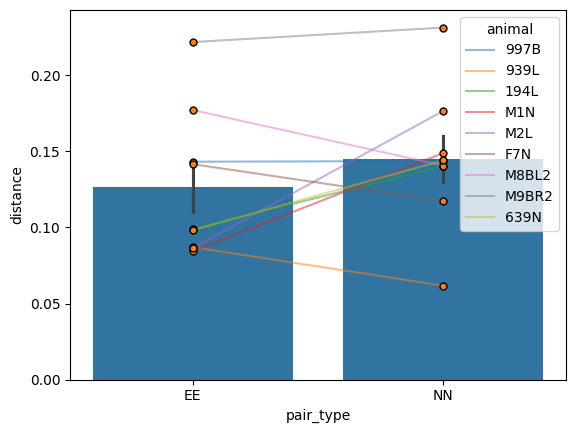

In [7]:
sb.barplot(data=riem_dist,x='pair_type',y='distance',errorbar='se')
sb.stripplot(data=riem_dist,x='pair_type',y='distance',linewidth=1,edgecolor='k',jitter=False)
sb.lineplot(data=riem_dist, x='pair_type', y='distance', hue='animal', legend=True, color='gray', alpha=0.5)

plt.show()

In [9]:
pg.normality(data=riem_dist)

,W,pval,normal
distance,0.937324,0.260648,True


In [10]:
pg.pairwise_tests(data=riem_dist,dv='distance',within=['pair_type'],subject='animal')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,pair_type,EE,NN,True,True,-1.247104,8.0,two-sided,0.247631,0.591,-0.37536


# D0 versus D4 (cs)

In [11]:
def mask_valid_pair(mat_a, mat_b):
    valid = (np.diag(mat_a) != 999) & (np.diag(mat_b) != 999)
    return mat_a[np.ix_(valid, valid)], mat_b[np.ix_(valid, valid)]

trace_s = 25
all_riem_dist_2 = []

for ani in animals:
    print(f"Processing {ani}...")
    mouse = animal(ani, 'FOV1', file_key=file_key, base_dir=base_dir)
    traces_df = mouse.load_traces(sessions=sessions, signal='events')
    cell_reg = mouse.load_cellreg()
    baseline_cols = cell_reg['Baseline'].loc[(cell_reg['Baseline']!=-1)&(cell_reg['Recall1']!=-1)].values
    recall1_cols  = cell_reg['Recall1'].loc[(cell_reg['Baseline']!=-1)&(cell_reg['Recall1']!=-1)].values

    baseline_act = traces_df['Baseline'].set_index('timestamps')
    recall1_act  = traces_df['Recall1'].set_index('timestamps')

    baseline_col_map = {ast.literal_eval(col)[1]: col for col in baseline_act.columns}
    recall1_col_map  = {ast.literal_eval(col)[1]: col for col in recall1_act.columns}

    baseline_act_matched = baseline_act[[baseline_col_map[idx] for idx in baseline_cols]]
    recall1_act_matched  = recall1_act[[recall1_col_map[idx]  for idx in recall1_cols]]

    v_bl = mouse.compute_velocity(sessions=['Baseline'], window_size=30, threshold=1)
    v_r1 = mouse.compute_velocity(sessions=['Recall1'],  window_size=30, threshold=1)

    t_baseline = baseline_act_matched.index.values
    t_recall1  = recall1_act_matched.index.values

    run_bool_bl = (v_bl > 0).squeeze()
    run_bool_r1 = (v_r1 > 0).squeeze()

    cs1_start, cs1_stop = mouse.load_tone_times(session_name='Recall1')

    # CS + trace windows in Recall1
    cs_trace_windows = [(float(s), float(e) + trace_s) for s, e in zip(cs1_start, cs1_stop)]
    cs_trace_mask = mask_from_windows(t_recall1, cs_trace_windows)

    # Baseline pool: before first CS onset minus 20s buffer
    bl_mask = mask_from_windows(t_baseline, [(0.0, float(cs1_start[0]) - 20.0)])

    # Match running composition of CS+trace in baseline
    n_run_cs  = int((cs_trace_mask & run_bool_r1).sum())
    n_rest_cs = int(cs_trace_mask.sum()) - n_run_cs

    try:
        bl_run_matched = sample_equal_frames(bl_mask & run_bool_bl, n_run_cs)
    except ValueError:
        n_run_cs = int((bl_mask & run_bool_bl).sum())
        bl_run_matched = bl_mask & run_bool_bl
        print(f"  Warning: only {n_run_cs} running frames in baseline; will trim cs_trace.")

    try:
        bl_rest_matched = sample_equal_frames(bl_mask & ~run_bool_bl, n_rest_cs)
    except ValueError:
        n_rest_cs = int((bl_mask & ~run_bool_bl).sum())
        bl_rest_matched = bl_mask & ~run_bool_bl
        print(f"  Warning: only {n_rest_cs} rest frames in baseline; will trim cs_trace.")

    bl_matched = bl_run_matched | bl_rest_matched

    n_bl_total = int(bl_matched.sum())
    n_total_cs = int(cs_trace_mask.sum())
    if n_bl_total < n_total_cs:
        cs_trace_mask = sample_equal_frames(cs_trace_mask, n_bl_total)
        print(f"  cs_trace trimmed {n_total_cs} → {n_bl_total} frames to match baseline.")

    print(f"  CS+trace frames: {cs_trace_mask.sum()}  (running={n_run_cs}, rest={n_rest_cs})")
    print(f"  Baseline matched frames: {bl_matched.sum()}")

    baseline_epoch = baseline_act_matched.loc[bl_matched]
    recall1_epoch  = recall1_act_matched.loc[cs_trace_mask]

    bl_engram     = baseline_epoch[[col for col in baseline_epoch.columns if ast.literal_eval(col)[0]]]
    bl_non_engram = baseline_epoch[[col for col in baseline_epoch.columns if not ast.literal_eval(col)[0]]]
    r1_engram     = recall1_epoch[[col for col in recall1_epoch.columns if ast.literal_eval(col)[0]]]
    r1_non_engram = recall1_epoch[[col for col in recall1_epoch.columns if not ast.literal_eval(col)[0]]]

    corr_matrices = {'baseline': {}, 'recall1': {}}
    for pop, df in {'engram': bl_engram, 'non_engram': bl_non_engram}.items():
        C = correlation(df.values.T)
        C.get_corr_matrix(method='spearman')
        corr_matrices['baseline'][pop] = C.corr
    for pop, df in {'engram': r1_engram, 'non_engram': r1_non_engram}.items():
        C = correlation(df.values.T)
        C.get_corr_matrix(method='spearman')
        corr_matrices['recall1'][pop] = C.corr

    with open(os.path.join(save_dir, f'{ani}_FOV1_corrmats_baseline_to_r1_reg_cstrace.pkl'), 'wb') as f:
        pickle.dump(corr_matrices, f)

    bl_eng, r1_eng = mask_valid_pair(corr_matrices['baseline']['engram'],
                                     corr_matrices['recall1']['engram'])
    bl_non, r1_non = mask_valid_pair(corr_matrices['baseline']['non_engram'],
                                     corr_matrices['recall1']['non_engram'])


    print('bl_eng:', (bl_eng == 999).any())
    print('bl_non:', (bl_non == 999).any())
    print('r1_eng:', (r1_eng == 999).any())
    print('r1_non:', (r1_non == 999).any())
    matrices = {
                'bl_eng': bl_eng,
                'bl_non': bl_non,
                'r1_eng': r1_eng,
                'r1_non': r1_non
            }

    for name, mat in matrices.items():
        eigenvalues = np.linalg.eigvalsh(mat)
        print(f"{name} | shape: {mat.shape}")
        print(f"{name} | min eig: {eigenvalues.min():.6f}, max eig: {eigenvalues.max():.6f}")
        print(f"{name} | is_spd: {np.all(eigenvalues > 0)}")
        print(f"{name} | has NaN: {np.isnan(mat).any()}, has Inf: {np.isinf(mat).any()}")
        print(f"{name} | value range: {mat.min():.4f} to {mat.max():.4f}")
        print()
        
    all_riem_dist_2.append({'animal': ani, 'pair_type': 'EE', 'distance': distRiemLE(bl_eng, r1_eng)/np.sqrt(bl_eng.shape[0])})
    all_riem_dist_2.append({'animal': ani, 'pair_type': 'NN', 'distance': distRiemLE(bl_non, r1_non)/np.sqrt(bl_non.shape[0])})

riem_dist_cs = pd.DataFrame(all_riem_dist_2)
riem_dist_cs.to_csv('/Users/amonast/Documents/GitHub/Amy_Reviews/data/riem_dist_tfc_d0vd4_cs.csv')

Processing 997B...
/Users/amonast/Desktop/Tone2P/Tagging/997B_FOV1_indices_split.csv
  cs_trace trimmed 13443 → 9764 frames to match baseline.
  CS+trace frames: 9764  (running=2153, rest=7611)
  Baseline matched frames: 9764
bl_eng: False
bl_non: False
r1_eng: False
r1_non: False
bl_eng | shape: (43, 43)
bl_eng | min eig: 0.782116, max eig: 1.221724
bl_eng | is_spd: True
bl_eng | has NaN: False, has Inf: False
bl_eng | value range: -0.0128 to 1.0000

bl_non | shape: (65, 65)
bl_non | min eig: 0.569265, max eig: 1.433150
bl_non | is_spd: True
bl_non | has NaN: False, has Inf: False
bl_non | value range: -0.0065 to 1.0000

r1_eng | shape: (43, 43)
r1_eng | min eig: 0.788130, max eig: 1.239164
r1_eng | is_spd: True
r1_eng | has NaN: False, has Inf: False
r1_eng | value range: -0.0131 to 1.0000

r1_non | shape: (65, 65)
r1_non | min eig: 0.730081, max eig: 1.310757
r1_non | is_spd: True
r1_non | has NaN: False, has Inf: False
r1_non | value range: -0.0094 to 1.0000

Processing 939L...
/Us

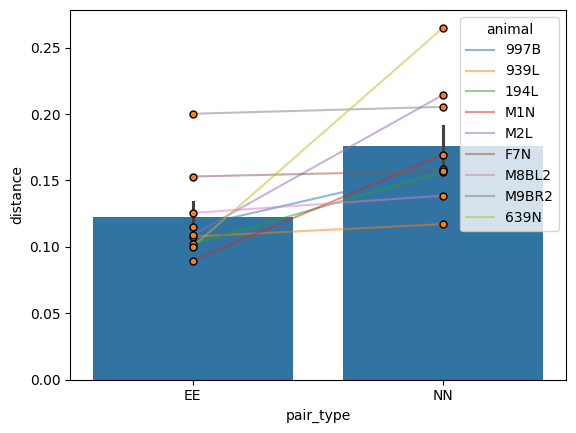

In [12]:
sb.barplot(data=riem_dist_cs,x='pair_type',y='distance',errorbar='se')
sb.stripplot(data=riem_dist_cs,x='pair_type',y='distance',linewidth=1,edgecolor='k',jitter=False)
sb.lineplot(data=riem_dist_cs, x='pair_type', y='distance', hue='animal', legend=True, color='gray', alpha=0.5)

plt.show()

In [13]:
pg.pairwise_tests(data=riem_dist,dv='distance',within=['pair_type'],subject='animal')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,pair_type,EE,NN,True,True,-1.247104,8.0,two-sided,0.247631,0.591,-0.37536


# within Recall1 Figure 5F

In [14]:
def load_data(ani,save_dir):
    with open(os.path.join(save_dir,f'{ani}_FOV1_corrmats_r1only.pkl'),'rb') as file:
        data = pickle.load(file)
    return data

In [ ]:
animals = ['997B','939L','194L','M1N','M2L','M5L','F5L','F7N','M8BL2','M9BR2','639N']
all_riem_dist_r1=[]
for ani in animals:

    print(f"Processing {ani}...")
    mouse = animal(ani, 'FOV1', file_key=file_key, base_dir=base_dir)
    
    try:
        corr_matrices=load_data(ani,save_dir)
        bl_eng, r1_eng = mask_valid_pair(corr_matrices['baseline']['engram'],
                                      corr_matrices['recall1']['engram'])
        bl_non, r1_non = mask_valid_pair(corr_matrices['baseline']['non_engram'],
                                        corr_matrices['recall1']['non_engram'])
    except:
        traces_df = mouse.load_traces(sessions=['Recall1'], signal='events')
        recall1_act = traces_df.set_index('timestamps')

        v_r1 = mouse.compute_velocity(sessions=['Recall1'], window_size=30, threshold=1)
        t_recall1  = recall1_act.index.values
        run_bool_r1 = (v_r1 > 0).squeeze()

        cs1_start, cs1_stop = mouse.load_tone_times(session_name='Recall1')

        # CS + trace windows
        cs_trace_windows = [(float(s), float(e) + trace_s) for s, e in zip(cs1_start, cs1_stop)]
        cs_trace_mask = mask_from_windows(t_recall1, cs_trace_windows)

        # Baseline pool: before first CS onset minus 20s buffer
        bl_mask = mask_from_windows(t_recall1, [(0.0, float(cs1_start[0]) - 20.0)])

        # Match running composition of CS+trace in baseline
        n_run_cs  = int((cs_trace_mask & run_bool_r1).sum())
        n_rest_cs = int(cs_trace_mask.sum()) - n_run_cs

        try:
            bl_run_matched = sample_equal_frames(bl_mask & run_bool_r1, n_run_cs)
        except ValueError:
            n_run_cs = int((bl_mask & run_bool_r1).sum())
            bl_run_matched = bl_mask & run_bool_r1
            print(f"  Warning: only {n_run_cs} running frames in baseline; will trim cs_trace.")

        try:
            bl_rest_matched = sample_equal_frames(bl_mask & ~run_bool_r1, n_rest_cs)
        except ValueError:
            n_rest_cs = int((bl_mask & ~run_bool_r1).sum())
            bl_rest_matched = bl_mask & ~run_bool_r1
            print(f"  Warning: only {n_rest_cs} rest frames in baseline; will trim cs_trace.")

        bl_matched = bl_run_matched | bl_rest_matched

        n_bl_total = int(bl_matched.sum())
        n_total_cs = int(cs_trace_mask.sum())
        if n_bl_total < n_total_cs:
            cs_trace_mask = sample_equal_frames(cs_trace_mask, n_bl_total)
            print(f"  cs_trace trimmed {n_total_cs} → {n_bl_total} frames to match baseline.")

        print(f"  CS+trace frames: {cs_trace_mask.sum()}  (running={n_run_cs}, rest={n_rest_cs})")
        print(f"  Baseline matched frames: {bl_matched.sum()}")

        baseline_epoch = recall1_act.loc[bl_matched]
        recall1_epoch  = recall1_act.loc[cs_trace_mask]

        bl_engram     = baseline_epoch[[col for col in baseline_epoch.columns if ast.literal_eval(col)[0]]]
        bl_non_engram = baseline_epoch[[col for col in baseline_epoch.columns if not ast.literal_eval(col)[0]]]
        r1_engram     = recall1_epoch[[col for col in recall1_epoch.columns if ast.literal_eval(col)[0]]]
        r1_non_engram = recall1_epoch[[col for col in recall1_epoch.columns if not ast.literal_eval(col)[0]]]

        corr_matrices = {'baseline': {}, 'recall1': {}}
        for pop, df in {'engram': bl_engram, 'non_engram': bl_non_engram}.items():
            C = correlation(df.values.T)
            C.get_corr_matrix(method='spearman')
            corr_matrices['baseline'][pop] = C.corr
        for pop, df in {'engram': r1_engram, 'non_engram': r1_non_engram}.items():
            C = correlation(df.values.T)
            C.get_corr_matrix(method='spearman')
            corr_matrices['recall1'][pop] = C.corr

        with open(os.path.join(save_dir, f'{ani}_FOV1_corrmats_r1only.pkl'), 'wb') as f:
            pickle.dump(corr_matrices, f)

        bl_eng, r1_eng = mask_valid_pair(corr_matrices['baseline']['engram'],
                                        corr_matrices['recall1']['engram'])
        bl_non, r1_non = mask_valid_pair(corr_matrices['baseline']['non_engram'],
                                        corr_matrices['recall1']['non_engram'])

    all_riem_dist_r1.append({'animal': ani, 'pair_type': 'EE', 'distance': distRiemLE(bl_eng, r1_eng)/np.sqrt(bl_eng.shape[0])})
    all_riem_dist_r1.append({'animal': ani, 'pair_type': 'NN', 'distance': distRiemLE(bl_non, r1_non)/np.sqrt(bl_non.shape[0])})

riem_dist_r1 = pd.DataFrame(all_riem_dist_r1)
riem_dist_r1.to_csv('/Users/amonast/Documents/GitHub/Amy_Reviews/data/riem_dist_tfc_recall1.csv')


Processing 997B...
Processing 939L...
Processing 194L...
Processing M1N...
Processing M2L...
Processing M5L...
Processing F5L...
Processing F7N...
Processing M8BL2...
Processing M9BR2...
Processing 639N...


<AxesSubplot: xlabel='pair_type', ylabel='distance'>

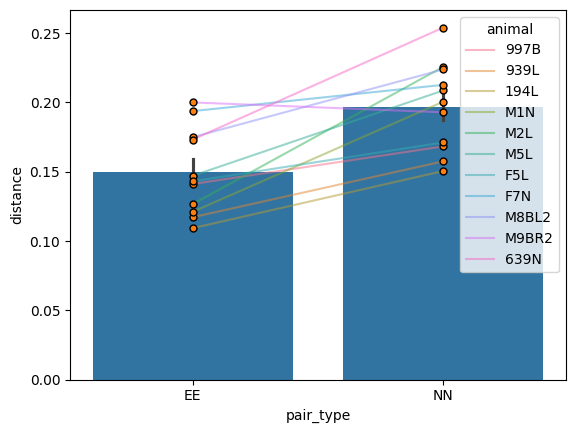

In [16]:
sb.barplot(data=riem_dist_r1,x='pair_type',y='distance',errorbar='se')
sb.stripplot(data=riem_dist_r1,x='pair_type',y='distance',linewidth=1,edgecolor='k',jitter=False)
sb.lineplot(data=riem_dist_r1, x='pair_type', y='distance', hue='animal', legend=True, color='gray', alpha=0.5)

In [17]:
pg.pairwise_tests(data=riem_dist_r1,dv='distance',within=['pair_type'],subject='animal')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,pair_type,EE,NN,True,True,-5.025767,10.0,two-sided,0.000517,70.618,-1.424674
